# Zero Initialization

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense

In [3]:
X, y = make_moons(
    n_samples = 500,
    noise = 0.2,
    random_state = 42
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

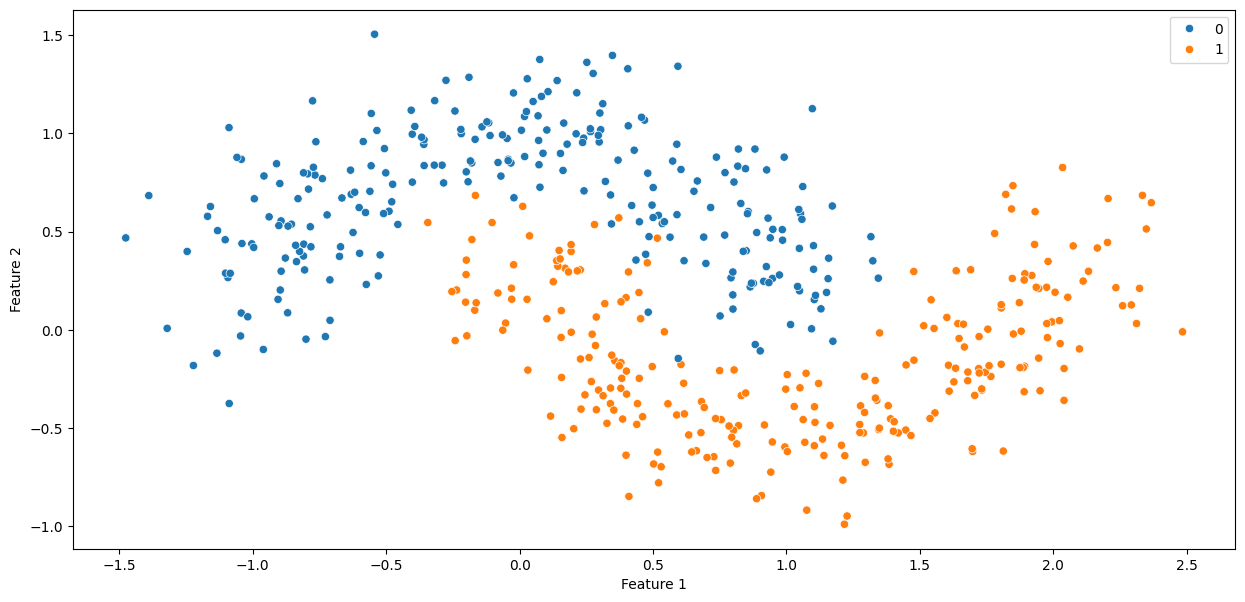

In [5]:
plt.figure(figsize = (15, 7))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [6]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(units = 2, activation='tanh'))
model.add(Dense(units = 1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.get_weights()

[array([[ 0.40767002, -1.1983159 ],
        [-0.58026916,  0.03621149]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.06331766],
        [0.12350953]], dtype=float32),
 array([0.], dtype=float32)]

In [8]:
initial_weights = model.get_weights()

initial_weights[0] = np.ones(model.get_weights()[0].shape)*0
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0

model.set_weights(initial_weights)
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [9]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
history = model.fit(X,y,epochs=100,validation_split=0.2, verbose = 0)

In [11]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.05093701], dtype=float32)]

> For tanh and relu activations, the weights will still remain as 0 but in the case of sigmoid activation, The weight will get updated but the weights which are initiated from every input becomes equal they are acting as perceptron

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

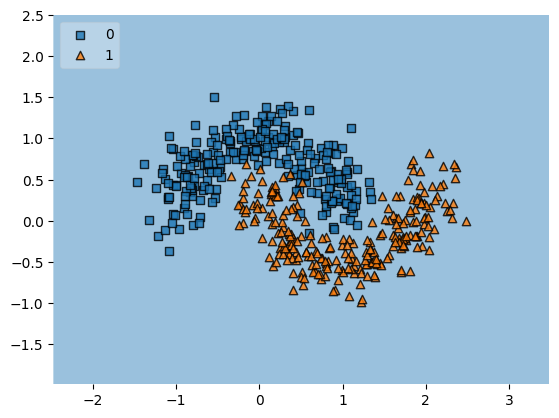

In [12]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [13]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(units = 2, activation='sigmoid'))
model.add(Dense(units = 1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
initial_weights = model.get_weights()

initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

model.set_weights(initial_weights)
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [15]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [16]:
history = model.fit(X,y,epochs=100,validation_split=0.2, verbose = 0)
model.get_weights()

[array([[-1.5132754, -1.5132754],
        [ 1.9059236,  1.9059236]], dtype=float32),
 array([-0.15660924, -0.15660924], dtype=float32),
 array([[-1.0170708],
        [-1.0170708]], dtype=float32),
 array([0.5562043], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

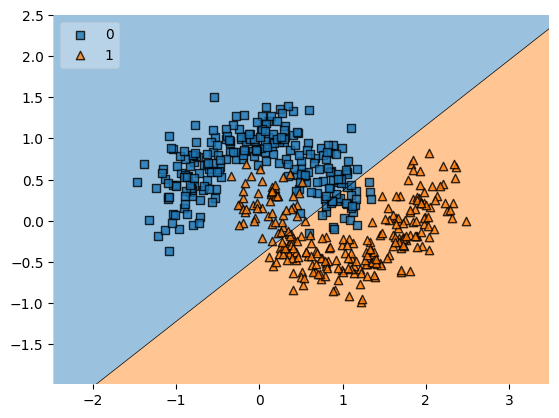

In [17]:
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

<hr>

# Non Zero Constant Initialization

In [23]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(2,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.get_weights()

[array([[-0.37184405, -0.3752666 ],
        [ 0.6044426 ,  0.5140946 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.3347516],
        [-1.3007134]], dtype=float32),
 array([0.], dtype=float32)]

In [25]:
initial_weights = model.get_weights()

initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

model.set_weights(initial_weights)
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [26]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [27]:
history = model.fit(X,y,epochs=100,validation_split=0.2, verbose = 0)

In [28]:
model.get_weights()

[array([[ 0.68613493,  0.68613493],
        [-0.7610055 , -0.7610055 ]], dtype=float32),
 array([-0.229839, -0.229839], dtype=float32),
 array([[1.0422329],
        [1.0422329]], dtype=float32),
 array([-0.061239], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

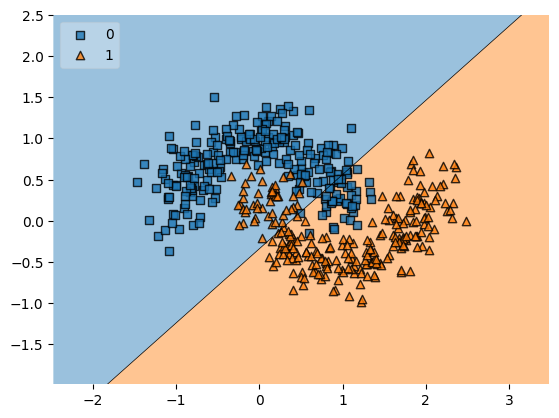

In [29]:
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

> Same observation with relu activation function

<hr>

> # Random Initialization
> Two varients
> - Small values - (0.001)
> - Big values - (0 to 1)

In [53]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(5,activation='tanh'))
model.add(Dense(5,activation='tanh'))
model.add(Dense(5,activation='tanh'))
model.add(Dense(5,activation='tanh'))
model.add(Dense(5,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                     │ (None, 5)                   │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
initial_weights = model.get_weights()

for i in range(len(initial_weights)):
    initial_weights[i] *= 0.001

model.set_weights(initial_weights)
model.get_weights()

[array([[ 0.00052513,  0.00044412, -0.00087178, -0.00041852,  0.00031959],
        [-0.0006465 ,  0.00071965, -0.00023187, -0.00017192,  0.0004241 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0.], dtype=float32),
 array([[-3.0297021e-04, -7.2598160e-04, -6.4539973e-04, -1.4044762e-05,
         -3.6434064e-04],
        [ 3.2581008e-04, -6.0508499e-04,  2.3764624e-04, -6.1415439e-04,
         -7.5940398e-04],
        [ 6.7348889e-04,  7.4292842e-04, -4.4150974e-04, -1.9334872e-04,
         -6.3850824e-04],
        [-3.2705427e-04,  6.3185685e-04, -2.0014579e-04, -5.2850891e-04,
          3.8760403e-04],
        [ 4.3270484e-04, -7.4328930e-04,  4.8972131e-04,  5.2253070e-04,
         -3.6905217e-04]], dtype=float32),
 array([0., 0., 0., 0., 0.], dtype=float32),
 array([[-1.72365020e-04,  1.26375497e-04,  5.41454472e-04,
          4.28958680e-04,  3.33065400e-05],
        [ 2.54102837e-04, -6.61349350e-06,  3.38536280e-04,
          4.53909423e-04, -3.30147654e-04],
        [ 6.1974

In [59]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [61]:
history = model.fit(X,y,epochs=500,validation_split=0.2)

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5072 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6958
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5519 - loss: 0.6910 - val_accuracy: 0.4500 - val_loss: 0.6959
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4885 - loss: 0.6940 - val_accuracy: 0.4500 - val_loss: 0.6957
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5090 - loss: 0.6930 - val_accuracy: 0.4500 - val_loss: 0.6957
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5038 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6957
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5189 - loss: 0.6925 - val_accuracy: 0.4500 - val_loss: 0.6958
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5074 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6958
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5092 - loss: 0.6930 - val_accuracy: 0.4500 -

In [62]:
model.get_weights()

[array([[ 0.00052511,  0.00044412, -0.00087177, -0.00041849,  0.00031957],
        [-0.00064647,  0.00071963, -0.00023186, -0.00017194,  0.00042411]],
       dtype=float32),
 array([-3.90252865e-11,  1.05851309e-12,  8.79150138e-12,  2.04103973e-11,
        -1.41593135e-11], dtype=float32),
 array([[-3.0291852e-04, -7.2598242e-04, -6.4541661e-04, -1.4093873e-05,
         -3.6427283e-04],
        [ 3.2580685e-04, -6.0508517e-04,  2.3764421e-04, -6.1415148e-04,
         -7.5940345e-04],
        [ 6.7345682e-04,  7.4292935e-04, -4.4149725e-04, -1.9331550e-04,
         -6.3855050e-04],
        [-3.2706579e-04,  6.3185528e-04, -2.0014093e-04, -5.2849855e-04,
          3.8758913e-04],
        [ 4.3270455e-04, -7.4328930e-04,  4.8972096e-04,  5.2253070e-04,
         -3.6905191e-04]], dtype=float32),
 array([ 6.0775518e-09,  2.3600677e-08,  2.7641740e-08, -1.9583526e-08,
         6.8861277e-09], dtype=float32),
 array([[-1.7233247e-04,  1.2634721e-04,  5.4141227e-04,  4.2895298e-04,
          

> Vanishing Gradient Problem
> In relu activation function the convergance become very slow

<hr>

> # Weight Initialization techniques

Xavier/Glorat initialization from scratch

In [77]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(10,activation='tanh',))
model.add(Dense(10,activation='tanh',))
model.add(Dense(10,activation='tanh',))
model.add(Dense(10,activation='tanh',))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.layers[4].get_config()['units']

1

In [86]:
# Weight Initialization
initial_weights = model.get_weights()

initial_weights[0] = np.random.randn(initial_weights[0].shape[0], initial_weights[0].shape[1]) * np.sqrt(1 / X_train.shape[1])
initial_weights[2] = np.random.randn(initial_weights[2].shape[0], initial_weights[2].shape[1]) * np.sqrt(1 / model.layers[0].get_config()['units'])
initial_weights[4] = np.random.randn(initial_weights[4].shape[0], initial_weights[4].shape[1]) * np.sqrt(1 / model.layers[1].get_config()['units'])
initial_weights[6] = np.random.randn(initial_weights[6].shape[0], initial_weights[6].shape[1]) * np.sqrt(1 / model.layers[2].get_config()['units'])
initial_weights[8] = np.random.randn(initial_weights[8].shape[0], initial_weights[8].shape[1]) * np.sqrt(1 / model.layers[3].get_config()['units'])

model.set_weights(initial_weights)
model.get_weights()

[array([[-0.21826427, -1.0676954 , -0.58615774,  1.4835478 , -0.26178   ,
          0.4589656 ,  0.08830943,  0.3376314 ,  0.04083461,  0.64539146],
        [-0.16579512, -0.849213  , -0.22944632, -0.22758628, -0.58212245,
          0.5294342 , -0.34563294,  0.35676548, -0.8598241 , -0.48936233]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.2057283 ,  0.45892692,  0.47991964, -0.34368262,  0.01917161,
         -0.0586166 , -0.28377837,  0.28320897,  0.32518438,  0.02699616],
        [ 0.12483824,  0.6253873 ,  0.11075674,  0.1281966 , -0.13990863,
         -0.13044013,  0.8809203 , -0.19274583, -0.20454164, -0.27738503],
        [ 0.5686877 , -0.2538112 , -0.08923682, -0.19098945,  0.39237893,
         -0.3793748 , -0.03547025,  0.00128   ,  0.3317689 ,  0.04333788],
        [ 0.17412964, -0.61931086,  0.5517034 ,  0.5943171 , -0.14549246,
         -0.12834668,  0.18490365,  0.04793575, -0.12181655,  0.29669955],
        [-0.14269

In [87]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [88]:
history = model.fit(X,y,epochs=500,validation_split=0.2, verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

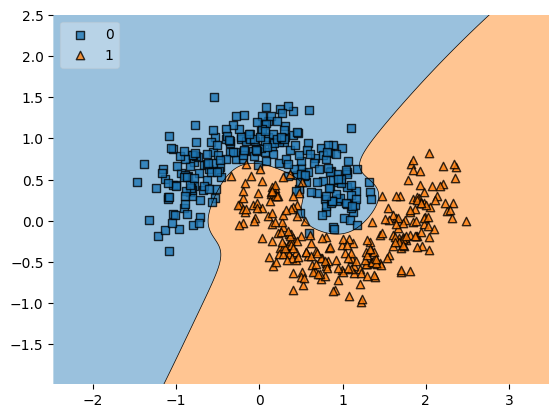

In [89]:
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

> # 1. Xavier/Glorat initialization

In [69]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(10,activation='tanh',kernel_initializer= keras.initializers.GlorotNormal()))
model.add(Dense(10,activation='tanh',kernel_initializer= keras.initializers.GlorotNormal()))
model.add(Dense(10,activation='tanh',kernel_initializer= keras.initializers.GlorotNormal()))
model.add(Dense(10,activation='tanh',kernel_initializer= keras.initializers.GlorotNormal()))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [71]:
history = model.fit(X,y,epochs=500,validation_split=0.2)

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5965 - loss: 0.6754 - val_accuracy: 0.8900 - val_loss: 0.6091
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8625 - loss: 0.5899 - val_accuracy: 0.8900 - val_loss: 0.5389
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8333 - loss: 0.5181 - val_accuracy: 0.8800 - val_loss: 0.4844
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8503 - loss: 0.4659 - val_accuracy: 0.8700 - val_loss: 0.4440
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8289 - loss: 0.4374 - val_accuracy: 0.8600 - val_loss: 0.4129
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8372 - loss: 0.4041 - val_accuracy: 0.8700 - val_loss: 0.3872
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8583 - loss: 0.3631 - val_accuracy: 0.8800 - val_loss: 0.3689
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8418 - loss: 0.3568 - val_accuracy: 0.8900 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


<Axes: >

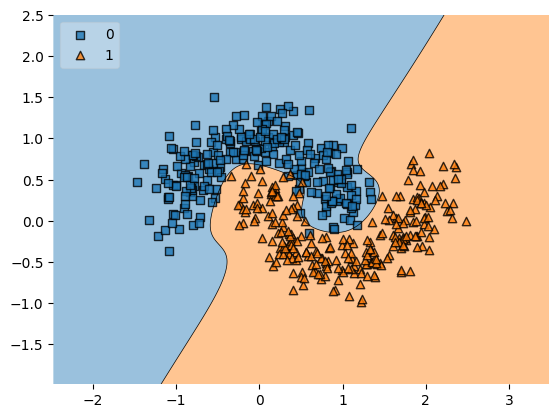

In [72]:
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

> # He Initialization

In [73]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(10,activation='relu',kernel_initializer= keras.initializers.HeNormal()))
model.add(Dense(10,activation='relu',kernel_initializer= keras.initializers.HeNormal()))
model.add(Dense(10,activation='relu',kernel_initializer= keras.initializers.HeNormal()))
model.add(Dense(10,activation='relu',kernel_initializer= keras.initializers.HeNormal()))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                     │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [75]:
history = model.fit(X,y,epochs=500,validation_split=0.2, verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step


<Axes: >

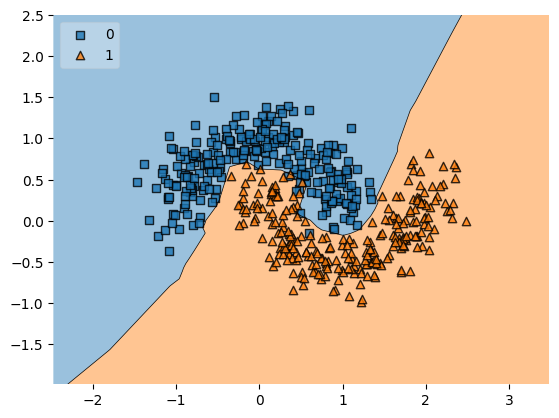

In [76]:
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)